# 05. Что кука делает с объявлениями

В прошлом ноутбуке признаки соседних действий немного помогли CatBoost, но прирост оказался неровным. Теперь попробуем связать события по `item_id`: просмотр, фото, страница продавца, контакт. Заодно посмотрим, как быстро идут просмотры и насколько кука меняет тематику объявлений.

Проверки останутся теми же, что раньше. Новый набор должен обойти CatBoost с маршрутами на будущих днях, иначе усложнять расчёт нет смысла. Код признаков лежит в `utils/journeys.py`. Ноутбук можно открыть из корня проекта или из папки `notebooks/`; Python 3.12 и версии библиотек указаны в `requirements.txt`.

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
from utils.features import build_features, events_in_windows
from utils.journeys import build_journey_features, CONTACT_EVENTS
from utils.metric import precision_at_recall

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 10})

root = Path("data")
train = pd.read_csv(root / "train.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(root / "test.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(root / "events.csv.gz", parse_dates=["event_ts"])
print(f"Python {sys.version.split()[0]} | train: {len(train):,} кук | test: {len(test):,} кук")

Python 3.12.10 | train: 11,091 кук | test: 4,909 кук


## Получится ли восстановить путь до контакта?

Сначала оставим только события из разрешённого окна каждой куки. `item_id` заполнен у просмотров, фото и контактных действий, поэтому технически их можно связать. Но окно длится лишь сутки: контакт с объявлением может быть виден без его просмотра в этих же сутках. Посчитаем, как часто это бывает.

Контактных объявлений: 17,896
Из них просмотр в этом же окне есть у 3,892, нет у 14,004


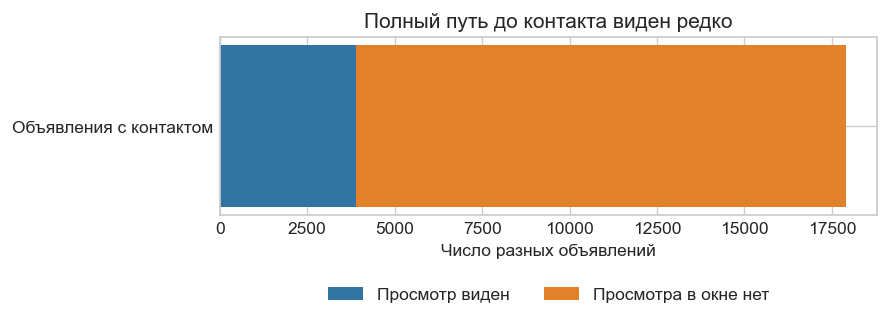

In [2]:
inside, _ = events_in_windows(train, test, events)
item_actions = inside.loc[inside.item_id.notna()]
pairs = pd.crosstab([item_actions.cookie_id, item_actions.item_id], item_actions.event_name)
for name in ["item_view", *CONTACT_EVENTS]:
    if name not in pairs:
        pairs[name] = 0
contacted = pairs[list(CONTACT_EVENTS)].sum(axis=1).gt(0)
viewed = pairs.item_view.gt(0)
contact_with_view = int((contacted & viewed).sum())
contact_without_view = int((contacted & ~viewed).sum())
print(f"Контактных объявлений: {contacted.sum():,}")
print(f"Из них просмотр в этом же окне есть у {contact_with_view:,}, нет у {contact_without_view:,}")

fig, ax = plt.subplots(figsize=(7, 2.4), layout="constrained")
ax.barh(["Объявления с контактом"], [contact_with_view], color="#3274A1",
        label="Просмотр виден")
ax.barh(["Объявления с контактом"], [contact_without_view],
        left=[contact_with_view], color="#E1812C", label="Просмотра в окне нет")
ax.set(xlabel="Число разных объявлений", title="Полный путь до контакта виден редко")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.32), ncol=2)
plt.show()

Только примерно каждое пятое объявление с контактом имеет просмотр в том же окне. Значит, признаки времени от просмотра до контакта будут заполнены не у всех. Нужны и более общие признаки: сколько разных объявлений кука просмотрела, сколько дошли до контакта, как менялись категория и продавец.

## Собираем три группы

- **Воронка**: число разных объявлений с просмотром, фото, избранным и контактом; доли пересечений и повторных действий.
- **Время**: паузы между просмотрами, первые фото и контакты после просмотра того же объявления. Если такой пары событий не было, значение остаётся пропуском.
- **Контекст**: смена категорий, локаций и типа продавца между просмотрами, возвраты к объявлению, совпадение просмотра с недавним поиском.

Данные train и test соединяем только для расчёта признаков отдельных кук. Метки в функцию не передаются, другие куки на признаки конкретной куки не влияют.

In [3]:
old_features, old_groups, n_inside = build_features(train, test, events)
journey_features, journey_groups = build_journey_features(train, test, events)
features = old_features.merge(
    journey_features.drop(columns="split"), on="cookie_id", how="left", validate="one_to_one"
)
X_train = features.iloc[:len(train)].reset_index(drop=True)
X_test = features.iloc[len(train):].reset_index(drop=True)
y = train.target.to_numpy()
base_columns = [column for column in old_groups["base"]
                if column not in {"headless_ua", "automation_ua", "ua_count"}]
route_columns = base_columns + old_groups["routes"]
new_columns = sum(journey_groups.values(), [])

assert X_train.cookie_id.equals(train.cookie_id)
assert X_test.cookie_id.equals(test.cookie_id)
assert len(new_columns) == len(set(new_columns))
assert not set(new_columns) & set(route_columns)
assert not np.isinf(features[new_columns].to_numpy(dtype=float)).any()
print(f"Событий внутри окон: {n_inside:,} из {len(events):,}")
print("Новых признаков:", {name: len(columns) for name, columns in journey_groups.items()})

Событий внутри окон: 288,126 из 328,905
Новых признаков: {'funnel': 12, 'timing': 10, 'context': 8}


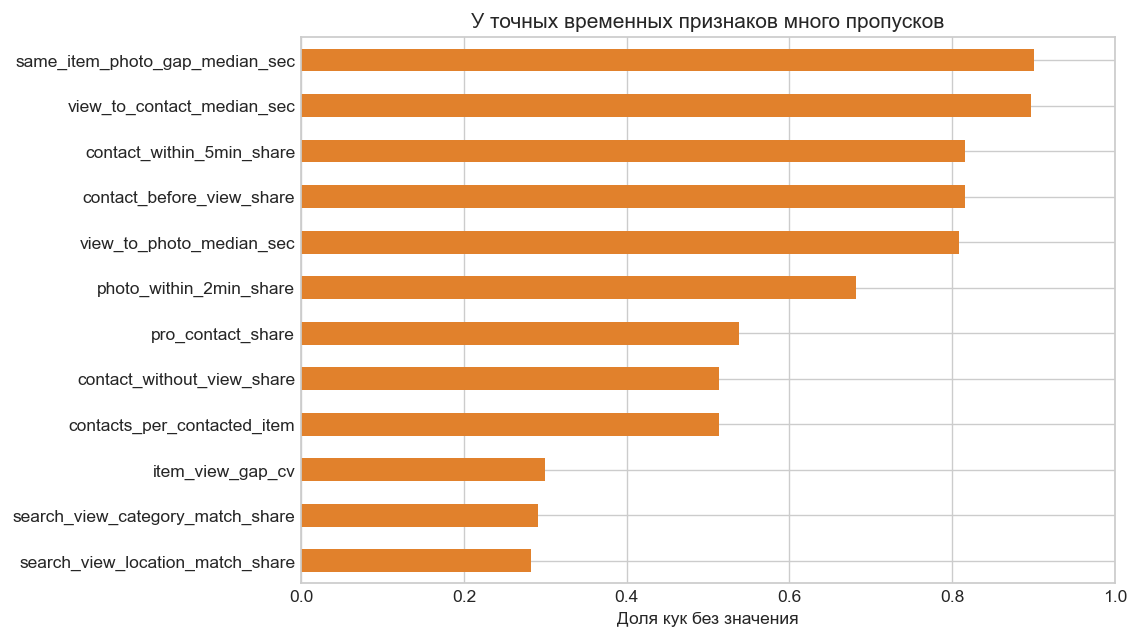

,доля пропусков
search_view_location_match_share,0.283
search_view_category_match_share,0.291
item_view_gap_cv,0.300
contacts_per_contacted_item,0.513
contact_without_view_share,0.513
pro_contact_share,0.537
photo_within_2min_share,0.681
view_to_photo_median_sec,0.809
contact_before_view_share,0.816
contact_within_5min_share,0.816


In [4]:
missing = X_train[new_columns].isna().mean().sort_values().tail(12)
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
missing.plot.barh(ax=ax, color="#E1812C")
ax.set(xlabel="Доля кук без значения", title="У точных временных признаков много пропусков", xlim=(0, 1))
plt.show()
display(missing.rename("доля пропусков").round(3).to_frame())

## Сравниваем с прежним CatBoost

Сохраняем параметры CatBoost из ноутбуков 03 и 04. Во всех вариантах меняется только набор признаков. Три проверочных отрезка идут по времени; модель не видит дни, которые наступят позже её проверки. Основная метрика всё та же: Precision при Recall не ниже 70%.

In [5]:
folds = [
    ("11–13 апреля", "2026-04-11", "2026-04-14"),
    ("14–16 апреля", "2026-04-14", "2026-04-17"),
    ("17–19 апреля", "2026-04-17", "2026-04-20"),
]
configs = {
    "routes": route_columns,
    "funnel": route_columns + journey_groups["funnel"],
    "timing": route_columns + journey_groups["timing"],
    "context": route_columns + journey_groups["context"],
    "funnel_timing": route_columns + journey_groups["funnel"] + journey_groups["timing"],
    "all_journey": route_columns + new_columns,
}
labels = {
    "routes": "Прежний CatBoost", "funnel": "+ воронка", "timing": "+ время",
    "context": "+ контекст", "funnel_timing": "+ воронка и время",
    "all_journey": "+ все новые",
}

def make_model():
    return CatBoostClassifier(
        iterations=600, depth=6, learning_rate=.05, l2_leaf_reg=5,
        loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE,
        thread_count=4, allow_writing_files=False,
    )

rows = []
validation_parts = []
for name, columns in configs.items():
    for fold_name, start, end in folds:
        fit = X_train.window_start_ts.lt(start).to_numpy()
        valid = (X_train.window_start_ts.ge(start) & X_train.window_start_ts.lt(end)).to_numpy()
        assert X_train.loc[fit, "window_start_ts"].max() < X_train.loc[valid, "window_start_ts"].min()
        model = make_model()
        model.fit(X_train.loc[fit, columns], y[fit])
        score = model.predict_proba(X_train.loc[valid, columns])[:, 1]
        rows.append({
            "model": name, "fold": fold_name,
            "p_at_r70": precision_at_recall(y[valid], score),
            "pr_auc": average_precision_score(y[valid], score),
        })
        validation_parts.append(pd.DataFrame({
            "cookie_id": X_train.loc[valid, "cookie_id"].to_numpy(),
            "fold": fold_name, "target": y[valid], "model": name, "score": score,
        }))
    print(f"Готово: {labels[name]}")
results = pd.DataFrame(rows)
validation_long = pd.concat(validation_parts, ignore_index=True)

Готово: Прежний CatBoost


Готово: + воронка


Готово: + время


Готово: + контекст


Готово: + воронка и время


Готово: + все новые


fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
model,,,,
Прежний CatBoost,0.484,0.509,0.596,0.530
+ воронка,0.507,0.504,0.546,0.519
+ время,0.496,0.515,0.554,0.522
+ контекст,0.495,0.537,0.571,0.534
+ воронка и время,0.511,0.544,0.518,0.524
+ все новые,0.480,0.477,0.528,0.495


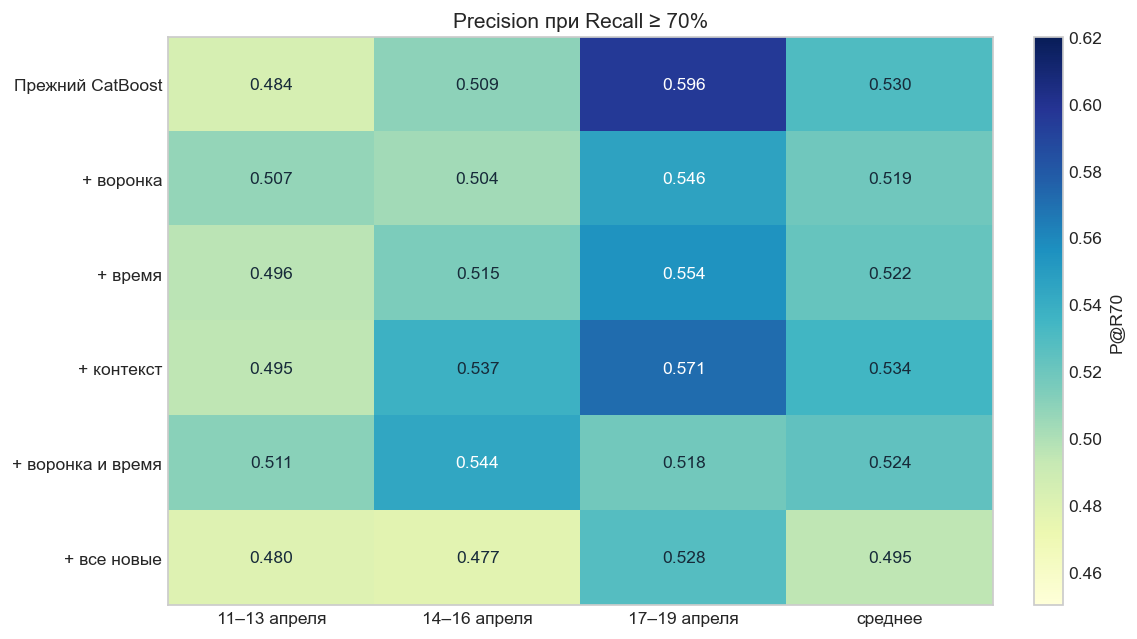

Прежний CatBoost воспроизведён: разница в score меньше 1e-8


In [6]:
summary = results.pivot(index="model", columns="fold", values="p_at_r70")
summary = summary[[name for name, _, _ in folds]]
summary["среднее"] = summary.mean(axis=1)
summary = summary.loc[list(configs)]
summary.index = summary.index.map(labels)
display(summary.round(3))

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
values = summary.to_numpy()
heat = ax.imshow(values, cmap="YlGnBu", vmin=.45, vmax=.62, aspect="auto")
ax.grid(False)
ax.set(xticks=range(len(summary.columns)), yticks=range(len(summary)),
       xticklabels=summary.columns, yticklabels=summary.index,
       title="Precision при Recall ≥ 70%")
for row in range(values.shape[0]):
    for column in range(values.shape[1]):
        ax.text(column, row, f"{values[row, column]:.3f}", ha="center", va="center",
                color="white" if values[row, column] > .54 else "#172b3a")
fig.colorbar(heat, ax=ax, label="P@R70")
plt.show()

old = pd.read_csv("output/feature_validation_scores.csv")
old_score = old.set_index("cookie_id").loc[
    validation_long.loc[validation_long.model.eq("routes"), "cookie_id"], "routes"
].to_numpy()
new_score = validation_long.loc[validation_long.model.eq("routes"), "score"].to_numpy()
assert np.max(np.abs(old_score - new_score)) < 1e-8
print("Прежний CatBoost воспроизведён: разница в score меньше 1e-8")

Воронка и временные признаки не дали устойчивого прироста. Это согласуется с тем, что точный путь до контакта часто не виден в пределах суток. Контекст поднял средний P@R70 с 0,530 до 0,534, но на последнем отрезке стало хуже: 0,571 вместо 0,596. Разница в среднем слишком мала, чтобы сразу менять прежнего кандидата.

## Проверяем контекст по частям

Контекст выглядит лучше остальных новых групп. Уберём его признаки по одному, затем проверим четыре понятных поднабора: только переключения, только тип продавца, только возвраты и только совпадение с поиском. Это поможет увидеть, не держится ли эффект на одной случайной детали.

In [7]:
context_columns = journey_groups["context"]
variants = {
    f"without_{removed}": route_columns + [c for c in context_columns if c != removed]
    for removed in context_columns
}
variants.update({
    "switches_only": route_columns + context_columns[:3],
    "seller_types_only": route_columns + [c for c in context_columns if c.startswith("pro_")],
    "returns_only": route_columns + ["return_to_item_share"],
    "search_matches_only": route_columns + [c for c in context_columns if c.startswith("search_view_")],
})
variant_rows = []
variant_predictions = []
for name, columns in variants.items():
    for fold_name, start, end in folds:
        fit = X_train.window_start_ts.lt(start).to_numpy()
        valid = (X_train.window_start_ts.ge(start) & X_train.window_start_ts.lt(end)).to_numpy()
        model = make_model()
        model.fit(X_train.loc[fit, columns], y[fit])
        score = model.predict_proba(X_train.loc[valid, columns])[:, 1]
        variant_rows.append({
            "variant": name, "fold": fold_name,
            "p_at_r70": precision_at_recall(y[valid], score),
        })
        variant_predictions.append(pd.DataFrame({
            "cookie_id": X_train.loc[valid, "cookie_id"].to_numpy(),
            "fold": fold_name, "target": y[valid], "model": name, "score": score,
        }))
variants_result = pd.DataFrame(variant_rows)
variant_summary = variants_result.pivot(index="variant", columns="fold", values="p_at_r70")
variant_summary = variant_summary[[name for name, _, _ in folds]]
variant_summary["среднее"] = variant_summary.mean(axis=1)
display(variant_summary.sort_values("среднее", ascending=False).round(3))

fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
variant,,,,
without_seller_switch_share,0.486,0.541,0.580,0.536
seller_types_only,0.470,0.533,0.583,0.529
without_search_view_location_match_share,0.490,0.529,0.563,0.527
switches_only,0.495,0.546,0.531,0.524
returns_only,0.502,0.454,0.609,0.521
without_pro_view_share,0.490,0.517,0.546,0.518
without_location_switch_share,0.491,0.529,0.523,0.515
without_search_view_category_match_share,0.456,0.555,0.528,0.513
search_matches_only,0.471,0.527,0.538,0.512


Лучшее среднее среди сокращённых вариантов получилось без `seller_switch_share`: 0,536. Это всего на 0,002 выше полного контекста и на 0,006 выше прежнего CatBoost. На последних днях прежняя модель всё равно лучше. Вариант только с возвратами добрался до 0,609 на последнем отрезке, но провалился на среднем. По одному удачному отрезку его выбирать нельзя.

## Проверка перестановкой

Для сокращённого контекста перемешаем по одному новому признаку на последнем отрезке. Если качество падает, модель использовала его в данном наборе. Результат может шуметь: признаки связаны друг с другом, а P@R70 резко меняется возле порога. Поэтому перестановка здесь служит подсказкой, не правилом окончательного отбора.

,mean,std
feature,,
category_switch_share,0.052,0.013
pro_contact_share,0.022,0.026
pro_view_share,0.020,0.007
return_to_item_share,0.019,0.016
search_view_location_match_share,0.007,0.009
location_switch_share,0.006,0.009
search_view_category_match_share,-0.002,0.007


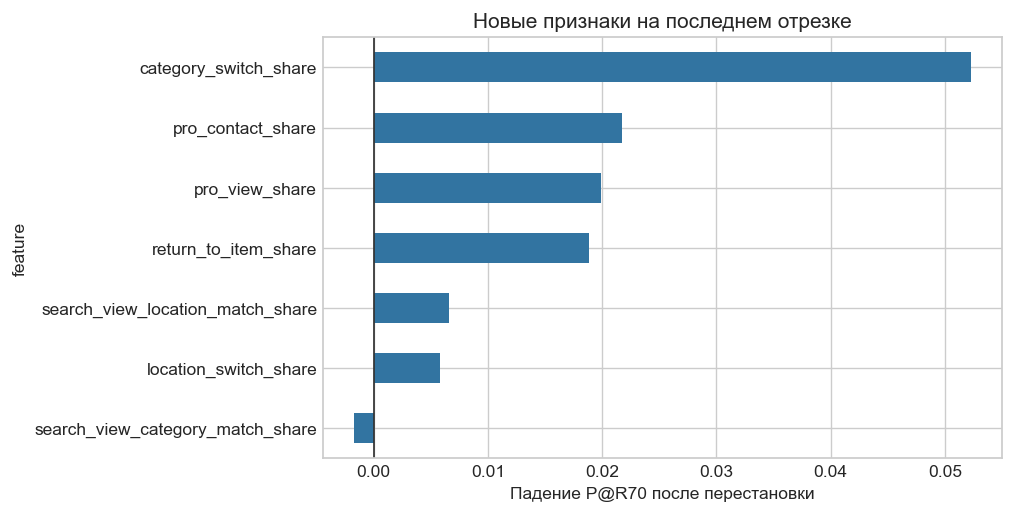

In [8]:
best_removed = variant_summary.loc[
    variant_summary.index.str.startswith("without_"), "среднее"
].idxmax().removeprefix("without_")
pruned_columns = route_columns + [c for c in context_columns if c != best_removed]
fit = X_train.window_start_ts.lt("2026-04-17").to_numpy()
valid = (X_train.window_start_ts.ge("2026-04-17")
         & X_train.window_start_ts.lt("2026-04-20")).to_numpy()
pruned_model = make_model()
pruned_model.fit(X_train.loc[fit, pruned_columns], y[fit])
valid_features = X_train.loc[valid, pruned_columns].copy()
reference = precision_at_recall(y[valid], pruned_model.predict_proba(valid_features)[:, 1])
rng = np.random.default_rng(RANDOM_STATE)
permutations = []
for column in context_columns:
    if column == best_removed:
        continue
    for repeat in range(5):
        shuffled = valid_features.copy()
        shuffled[column] = rng.permutation(shuffled[column].to_numpy())
        score = pruned_model.predict_proba(shuffled)[:, 1]
        permutations.append({"feature": column, "drop": reference - precision_at_recall(y[valid], score)})
permutation_table = pd.DataFrame(permutations).groupby("feature")["drop"].agg(["mean", "std"])
permutation_table = permutation_table.sort_values("mean", ascending=False)
display(permutation_table.round(3))

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
permutation_table.sort_values("mean")["mean"].plot.barh(ax=ax, color="#3274A1")
ax.axvline(0, color="#333333", linewidth=1)
ax.set(xlabel="Падение P@R70 после перестановки", title="Новые признаки на последнем отрезке")
plt.show()

## Оставляем кандидатов для заключения

Сохраним оценки всех основных групп и сокращённого контекста. Для test обучим эти варианты на всём train. Это не готовый файл для отправки: в заключении ещё нужно сравнить ошибки моделей и решить, помогает ли смешивание их оценок.

In [9]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
validation_path = output_dir / "journey_validation_scores.csv"
test_path = output_dir / "journey_test_scores.csv"

variant_long = pd.concat(variant_predictions, ignore_index=True)
selected_long = variant_long.loc[
    variant_long.model.eq(f"without_{best_removed}")
].copy()
selected_long["model"] = "context_pruned"
all_validation = pd.concat([validation_long, selected_long], ignore_index=True)
validation_wide = all_validation.pivot(
    index=["cookie_id", "fold", "target"], columns="model", values="score"
).reset_index()
validation_wide.columns.name = None
validation_wide.to_csv(validation_path, index=False, float_format="%.10f")

test_configs = {**configs, "context_pruned": pruned_columns}
test_candidates = pd.DataFrame({"cookie_id": test.cookie_id})
for name, columns in test_configs.items():
    model = make_model()
    model.fit(X_train[columns], y)
    test_candidates[name] = model.predict_proba(X_test[columns])[:, 1]
test_candidates.to_csv(test_path, index=False, float_format="%.10f")

assert len(validation_wide) == len(old) and validation_wide.cookie_id.is_unique
assert validation_wide[list(test_configs)].notna().all().all()
assert test_candidates.cookie_id.equals(test.cookie_id)
assert test_candidates.drop(columns="cookie_id").apply(lambda s: s.between(0, 1).all()).all()
assert pd.read_csv(test_path).cookie_id.equals(test.cookie_id)
print(f"Сохранены {validation_path} и {test_path}")
print("Test:", len(test_candidates), "кук")

Сохранены output/journey_validation_scores.csv и output/journey_test_scores.csv
Test: 4909 кук


## Что получилось

Мы проверили ещё 30 признаков. У точного пути от просмотра до контакта много пропусков, потому что в суточном окне часто видна лишь часть истории объявления. Из трёх групп только контекст дал небольшой прирост среднего качества. Лучший сокращённый вариант получил 0,536 против 0,530 у прежнего CatBoost с маршрутами, но на последнем отрезке уступил ему: 0,580 против 0,596.

Сильного нового победителя пока нет. Контекстные признаки и их предсказания сохранили для финального сравнения; выбирать модель по одному удачному числу было бы слишком рискованно. Все признаки рассчитаны только из событий до конца окна куки. Скрытые метки test нам недоступны.